# Military Maintenance Manual Assistant - RAG Application

A Retrieval-Augmented Generation (RAG) system for querying FAR/DFARS defense acquisition regulations using natural language.

**Stack:** LangChain | ChromaDB | HuggingFace Embeddings | Ollama (Mistral)

**RAG Pipeline:**
1. Load PDF documents
2. Chunk into overlapping segments
3. Embed chunks into a vector store (ChromaDB)
4. Retrieve relevant chunks via semantic search (MMR)
5. Generate groudned answers via Ollama

## 1. Environment and Imports

In [1]:
# Standard library
import os
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
# Document loading
from langchain_community.document_loaders import PyPDFLoader
# Text splitting
from langchain_text_splitters import RecursiveCharacterTextSplitter
# Embeddings
from langchain_huggingface import HuggingFaceEmbeddings
# Vector store
from langchain_chroma import Chroma
# LLM
from langchain_ollama import ChatOllama
# RAG chain components
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.messages import HumanMessage, AIMessage

## 2. Load Documents

Load FAR PDF files from the data/ folder. Each page becomes a Document object with the text content and metadata (source filename, page number).

In [2]:
# data folder
DATA_DIR = Path("data")
# load all PDFs in the folder
documents = []

pdf_files = list(DATA_DIR.glob("*.pdf"))
print(f"{len(pdf_files)} PDF(s) Found")

for pdf_path in pdf_files:
    print(f" Loading: {pdf_path.name}")
    loader = PyPDFLoader(str(pdf_path))
    pages = loader.load()
    documents.extend(pages)
    print(f"   -> {len(pages)} pages loaded")

print(f"\nTotal pages loaded: {len(documents)}")

3 PDF(s) Found
 Loading: FAR Part 12 - Acquisition of Commercial Products and Commercial Services.pdf
   -> 21 pages loaded
 Loading: FAR Part 15 - Contracting by Negotiation.pdf
   -> 63 pages loaded
 Loading: FAR Part 46 - Quality Assurance.pdf
   -> 25 pages loaded

Total pages loaded: 109


In [3]:
# examine sample from first document
sample = documents[0]

print("--- First 500 chars ---\n",sample.page_content[:500])
print("\n--- Metadata ---\n", sample.metadata)

--- First 500 chars ---
 Part 12 - Acquisition of Commercial Products and
Commercial Services
12.000 Scope of part.
12.001 Definition.
Subpart 12.1 - Acquisition of Commercial Products and Commercial Services
12.101 Policy.
12.102 Applicability.
12.103 Commercially available off-the-shelf (COTS) items.
Subpart 12.2 - Special Requirements for the Acquisition of Commercial Products and Commercial Services
12.201 General.
12.202 Market research and description of agency need.
12.203 Procedures for solicitation, evaluation,

--- Metadata ---
 {'producer': 'Skia/PDF m149', 'creator': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/149.0.0.0 Safari/537.36', 'creationdate': '2026-06-11T14:44:31+00:00', 'title': 'Part 12 - Acquisition of Commercial Products and Commercial Services', 'moddate': '2026-06-11T14:44:31+00:00', 'source': 'data\\FAR Part 12 - Acquisition of Commercial Products and Commercial Services.pdf', 'total_pages': 21, 'page': 0, 'page_l

In [4]:
# spot check middle of the corpus
sample_mid = documents[50]

print("--- Source ---\n", sample_mid.metadata['title'])
print(f"Page {sample_mid.metadata['page_label']} of {sample_mid.metadata['total_pages']}")
print("\n--- Content Preview ---\n", sample_mid.page_content[:300])

--- Source ---
 Part 15 - Contracting by Negotiation
Page 30 of 63

--- Content Preview ---
 set forth in the proposal(s) in order to determine the need for and reasonableness of the proposed resources, assumingreasonable economy and efficiency.
(2) At a minimum, the technical analysis should examine the types and quantities of material proposed and the need for thetypes and quantities of l


## 3. Chunk Documents
+ Split pages into smaller overlapping chunks for embedding.
+ Embedding models have token limits and work better on focused passages than full pages. Overlapping chunks prevent context loss at boundaries.

**Choices made:**
- chunk_size=1000: captures enough context for regulatory language without exceeding embedding model limits
- chunk_overlap=200: ensures sentences that straddle chunk boundaries aren't lost 
- RecursiveCharacterTextSplitter: splits on paragraph breaks first, then sentences, then words — preserves semantic units over arbitrary cuts

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = splitter.split_documents(documents)

print(f"Pages: {len(documents)}")
print(f"Chunks: {len(chunks)}")
print(f"Avg chunk size: {sum(len(c.page_content) for c in chunks) // len(chunks)} chars")

# inspect a single chunk
print("\n --- Sample Chunk ---")
print(chunks[10].page_content)
print("\n--- Chunk Metadata ---")
print(chunks[10].metadata)

Pages: 109
Chunks: 499
Avg chunk size: 795 chars

 --- Sample Chunk ---
applicable to COTS (in addition to 12.503 and 12.504).
Subpart 12.2 - Special Requirements for the Acquisition of
Commercial Products and Commercial Services
12.201 General.
This subpart identifies special requirements for the acquisition of commercial products and commercial services
intended to more closely resemble those customarily used in the commercial marketplace, as well as other
considerations necessary for proper planning, solicitation, evaluation, and award of contracts for commercial
products and commercial services.
12.202 Market research and description of agency need.
(a) Market research (see 10.001) is an essential element of building an effective strategy for the acquisition of
commercial products and commercial services and establishes the foundation for the agency description of need
(see part  11), the solicitation, and resulting contract.
(b) The description of agency need must contain sufficie

## 4. Embed and Store in ChromaDB

Convert chunks into vector embeddings and store in ChromaDB.

**Embedding model:** sentence-transformers/all-MiniLM-L6-v2
- Free, runs locally on CPU
- 384-dimensional dense vectors
- Strong performance on English semantic similarity tasks
- ~90MB download, cached after first run

**ChromaDB Choice**
- Runs locally, no server needed
- Persists to disk so we don't re-embed every time
- Simple API that translates directly to Pinecone/Weaviate in production

In [6]:
# optional: load existing vector store after first run
# vectorstore = Chroma(
#     collection_name="far_docs",
#     embedding_function=embeddings,
#     persist_directory=CHROMA_DIR
# )

In [7]:
# load embedding model
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device":"cpu"},
    encode_kwargs={"normalize_embeddings":True}
)
# test embedding model on one sentence
test_vector = embeddings.embed_query("What are the requirments for commercial acquisitions?")
print(f"Vector dimensions: {len(test_vector)}")
print(f"First 5 values: {[round(v, 4) for v in test_vector[:5]]}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vector dimensions: 384
First 5 values: [0.035, -0.026, -0.0247, -0.0491, -0.0103]


In [8]:
# build the vector store
print(f"Embedding {len(chunks)} chunks and storing in ChromaDB..")

CHROMA_DIR = "chroma_db"

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="far_docs",
    persist_directory=CHROMA_DIR
)

print(f"\nVector store built successfully")
print(f"Storage location: {CHROMA_DIR}/")
print(f"Collection: far_docs")
print(f"Documents in store: {vectorstore._collection.count()}")

Embedding 499 chunks and storing in ChromaDB..

Vector store built successfully
Storage location: chroma_db/
Collection: far_docs
Documents in store: 3493


## 5. Retrieve

Query the vector store to find the most relevant chunks for a given question.

**Search type: MMR (Maximal Marginal Relevance)**
- Pure similarity search returns the top-k most similar chunks, which are often near-duplicates from adjacent pages
- MMR adds a diversity penalty — it picks chunks that are relevant to the query but not redundant with each other
- Result: broader coverage of the answer space per query

**Parameters:**
- k=5: return 5 chunks
- fetch_k=20: MMR considers 20 candidates before selecting the best 5

In [9]:
retriever = vectorstore.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k":5,
        "fetch_k":20
    }
)

# test retrieval with relevant question
test_query = "What are the requirements for acquiring commercial products?"

retrieved_docs = retriever.invoke(test_query)

print(f"Query: {test_query}")
print(f"Chunks retrieved: {len(retrieved_docs)}")
print()
print('-'*50)

for i, doc in enumerate(retrieved_docs):
    print(f"\n--- Chunk {i+1} ---")
    print(f"Source: {doc.metadata['title']}")
    print(f"Page: {doc.metadata['page_label']}")
    print(f"Text: {doc.page_content[:200]}...")

Query: What are the requirements for acquiring commercial products?
Chunks retrieved: 5

--------------------------------------------------

--- Chunk 1 ---
Source: Part 12 - Acquisition of Commercial Products and Commercial Services
Page: 4
Text: (see part  11), the solicitation, and resulting contract.
(b) The description of agency need must contain sufficient detail for potential offerors of commercial products or
commercial services to know...

--- Chunk 2 ---
Source: Part 12 - Acquisition of Commercial Products and Commercial Services
Page: 4
Text: (see part  11), the solicitation, and resulting contract.
(b) The description of agency need must contain sufficient detail for potential offerors of commercial products or
commercial services to know...

--- Chunk 3 ---
Source: Part 12 - Acquisition of Commercial Products and Commercial Services
Page: 4
Text: (see part  11), the solicitation, and resulting contract.
(b) The description of agency need must contain sufficient detail for 

## 6. Generate (RAG chain + Ollama)

Connect the retriever to Ollama to produce grounded answers.

**Components:**
- Prompt template: instructs the model to answer only from retrieved context, cite sources, and admit when it doesn't know
- create_stuff_documents_chain: injects retrieved chunks into the prompt context
- create_retrieval_chain: wires retriever + stuff chain into one callable
- Chat history: allows follow-up questions with memory of prior turns

In [10]:
SYSTEM_PROMPT = """You are an expert assistant on FAR and DFARS defense acquisition 
regulations. Answer questions using ONLY the context provided below.

Rules:
- Base your answer strictly on the provided context
- Cite the specific FAR part and page number your answer comes from
- If the context does not contain enough information to answer, say:
  "The loaded documents don't cover that specifically. You may want to check
  FAR Part [suggest a relevant part number]."
- Be precise — for regulatory language, quote the exact text when relevant
- Do not speculate or add information beyond what the context states

Context:
{context}"""

prompt = ChatPromptTemplate.from_messages([
    ("system",SYSTEM_PROMPT),
    MessagesPlaceholder("chat_history"),
    ("human","{input}"),
])

In [11]:
# initialize ollama
llm = ChatOllama(
    model="mistral",
    temperature=0.1 # low temp = factual answers, high temp = more creative and unideal for regulatory Q&A
    # temperature=0
)

# build the chain
combine_docs_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retriever, combine_docs_chain)

In [12]:
chat_history = []

question = "What are the requirements for acquiring commercial products?"

result = rag_chain.invoke({
    "input":question,
    "chat_history":chat_history
})

print(f"QUESTION:\n{question}")
print(f"\nANSWER:\n{result['answer']}")
print()
print('-'*50)
print("SOURCES:")
for doc in result['context']:
    print(f" - {doc.metadata['title']} | Page {doc.metadata['page_label']}")

QUESTION:
What are the requirements for acquiring commercial products?

ANSWER:
 To acquire commercial products, the following requirements apply according to the provided context:

1. The description of agency need must contain sufficient detail for potential offerors to know which commercial products may be suitable (FAR 12.202(b)). This should include the type of commercial product and how it will be used in terms of function, performance requirements, or essential physical characteristics.

2. For acquisitions expected to exceed the simplified acquisition threshold, a detailed description of agency need is mandatory (FAR 12.202(b)(i)). If a paper solicitation or contract is being issued and procedures at 12.603 are not being used, this detailed description is also required (FAR 12.202(b)(ii)).

3. Market research is an essential element of building an effective strategy for the acquisition of commercial products and establishes the foundation for the agency's description of need (F

In [13]:
# update chat history w/ the new exchange
chat_history.append(HumanMessage(content=question))
chat_history.append(AIMessage(content=result['answer']))

# ask follow up question that requires remembering the first answer
followup = "What specific clauses must be included in those contracts?"

result2 = rag_chain.invoke({
    'input':followup,
    'chat_history':chat_history
})

print(f'FOLLOW UP:\n{followup}')
print(f"\nANSWER:\n{result2['answer']}")
print()
print('-'*50)
print('SOURCES:')
for doc in result2['context']:
    print(f" - {doc.metadata['title']} | Page {doc.metadata['page_label']}")

# update chat history again
chat_history.append(HumanMessage(content=followup))
chat_history.append(AIMessage(content=result2['answer']))

FOLLOW UP:
What specific clauses must be included in those contracts?

ANSWER:
 Based on the provided context, the following specific clauses must be included in contracts:

1. For contracts requiring the performance of services, the clause at 52.246-25, Limitation of Liability-Services (FAR 46.804(a)(4)).
2. In contracts requiring both the performance of services and the delivery of end items:
   a. The clause prescribed in paragraph (a)(4) of this section (52.246-25, Limitation of Liability-Services).
   b. The appropriate clause or clauses prescribed in paragraphs (a)(1), (a)(2), or (a)(3) of this section for the specific acquisition. Identify clearly in the contract schedule any high-value line items (FAR 46.804(a)(5)).

These clauses are only required when the contract amount is expected to be in excess of the simplified acquisition threshold and the contract is subject to the requirements of FAR Part 46 as indicated in 46.801. For contracts at or below the simplified acquisition 

## 7. Evaluation

**Evaluation Strategy**  
Question/answer pairs where the correct answer is known in advance. Use it to measure:
1. Retrieval quality: did the correct chunks come back?
2. Answer faithfulness: is answer grounded in the retrieved context?
3. Chunk sensitivity: how does chunk_size affect both metrics?

**However**  
I am not actually an expert in these documents. Therefore I will be using the RAG system itself to discover what is in the documents, then building my evaluation dataset that I can verify.

In [14]:
discovery_queries = [
    "What dollar thresholds are mentioned for contract requirements?",
    "What specific clause numbers are required in commercial contracts?",
    "What are the time limits or deadlines mentioned for any procedures?",
    "What are the quality assurance requirements for contracts?",
    "What are the definitions of key terms like commercial product or offeror?",
]

for query in discovery_queries:
    print(f"\nQUERY: {query}")
    print('-'*50)
    r = rag_chain.invoke({'input':query, "chat_history":[]})
    print(r['answer'])
    print()


QUERY: What dollar thresholds are mentioned for contract requirements?
--------------------------------------------------
 The provided context mentions two dollar thresholds for contract requirements:

1. For submitting certified cost or pricing data, the lower of either $20 million or more, or more than the pertinent certified cost or pricing data threshold and more than 10 percent of the prime contractor’s proposed price (FAR 15.403-1(c)(1)).

2. The simplified acquisition threshold, but it is not explicitly stated what this threshold is in the provided context. However, it can be found in FAR Part 2.1, which states that the simplified acquisition threshold is $250,000 for commercial items and $150,000 for other than commercial items (FAR 2.101).


QUERY: What specific clause numbers are required in commercial contracts?
--------------------------------------------------
 The specific clause numbers required in commercial contracts, according to the provided context, are:

1. 52.21

In [15]:
evaluation_dataset = [
    {
        "question": "What is the subcontract dollar threshold mentioned for contract requirements?",
        "expected_keywords": ["20 million", "subcontract"],
        "note": "Should cite a specific dollar figure"
    },
    {
        "question": "What clause is required for basic safeguarding of covered contractor information systems?",
        "expected_keywords": ["52.204-21", "safeguarding", "information systems"],
        "note": "Should cite exact clause number"
    },
    {
        "question": "What is the deadline for offerors to submit proposals when no time is specified?",
        "expected_keywords": ["4:30", "PM"],
        "note": "Should cite the specific time"
    },
    {
        "question": "What FAR parts govern quality assurance requirements for contracts?",
        "expected_keywords": ["46.202", "46.203"],
        "note": "Should cite specific FAR subparts"
    },
    {
        "question": "What is the definition of a commercial product under FAR?",
        "expected_keywords": ["supply system", "alternate", "replacement"],
        "note": "Should match the specific FAR definition language"
    },
]

In [16]:
def evaluate_rag(retriever, rag_chain, dataset):
    results = []

    for i, item in enumerate(dataset):
        question = item['question']
        expected_keywords = item['expected_keywords']
        print(f"Running test {i+1}/{len(dataset)}: {question[:60]}...")
        # get retreived chunks
        retrieved_docs = retriever.invoke(question)
        # get answer
        result = rag_chain.invoke({
            'input':question,
            'chat_history':[]
        })
        answer = result['answer']
        # check retrieval quality - do expected keywords appear in chunks?
        combined_context = " ".join([d.page_content.lower() for d in retrieved_docs])
        keyword_hits = {kw: (kw.lower() in combined_context) for kw in expected_keywords}
        retrieval_score = sum(keyword_hits.values()) / len(keyword_hits)
        # check answer quality - do expected keywords appear in answer?
        answer_hits = {kw: (kw.lower() in answer.lower()) for kw in expected_keywords}
        answer_score = sum(answer_hits.values()) / len(answer_hits)
        # source quality
        sources = list(set([
            d.metadata.get('title','unknown') for d in retrieved_docs
        ]))
        # record results
        results.append({
            'question':question,
            'answer':answer,
            'retrieval_score':retrieval_score,
            'answer_score':answer_score,
            'keyword_hits_retrieval':keyword_hits,
            'keyword_hits_answer':answer_hits,
            'sources':sources,
            'note':item['note']
        })

    return results

In [17]:
eval_results = evaluate_rag(retriever, rag_chain, evaluation_dataset)

for r in eval_results:
    print(f"\nQUESTION: {r['question']}")
    print(f"  Retrieval score: {r['retrieval_score']*100:.0f}%  {r['keyword_hits_retrieval']}")
    print(f"  Answer score: {r['answer_score']*100:.0f}%  {r['keyword_hits_answer']}")
    print(f"  Sources: {r['sources']}")
    print(f"  Answer preview: {r['answer'][:200]}")

# eval summary
avg_retrieval = sum(r['retrieval_score'] for r in eval_results) / len(eval_results)
avg_answer = sum(r['answer_score'] for r in eval_results) / len(eval_results)

print()
print('-'*50)
print("SUMMARY")
print('-'*50)
print(f"Avg retrieval score: {avg_retrieval*100:.0f}%")
print(f"Avg answer score: {avg_answer*100:.0f}%")
print(f"Chunk size used: {splitter._chunk_size}")
print(f"Chunk overlap used: {splitter._chunk_overlap}")

Running test 1/5: What is the subcontract dollar threshold mentioned for contr...
Running test 2/5: What clause is required for basic safeguarding of covered co...
Running test 3/5: What is the deadline for offerors to submit proposals when n...
Running test 4/5: What FAR parts govern quality assurance requirements for con...
Running test 5/5: What is the definition of a commercial product under FAR?...

QUESTION: What is the subcontract dollar threshold mentioned for contract requirements?
  Retrieval score: 100%  {'20 million': True, 'subcontract': True}
  Answer score: 100%  {'20 million': True, 'subcontract': True}
  Sources: ['Part 15 - Contracting by Negotiation']
  Answer preview:  The subcontract dollar threshold mentioned for requiring certified cost or pricing data is $20 million or more, or both more than the pertinent certified cost or pricing data threshold and more than 

QUESTION: What clause is required for basic safeguarding of covered contractor information systems?
 

### Baseline Results - chunk_size=1000, chunk_overlap=200
- Avg retrieval score: 80%
- Avg answer score: 50%

The gap between retrieval and answer scores suggests the retriever is finding relevant chunks but the LLM is not always surfacing the specific terms in its response. Possible causes:
- LLM paraphrases instead of quoting exact regulatory language
- Expected keywords too specific (exact clause numbers, exact dollar figures)
- Chunk size may be splitting critical context across boundaries

In [18]:
# chunk size experiment function
def build_vectorstore_with_chunk_size(documents, embeddings, chunk_size, chunk_overlap):
    """Build a fresh vectorstore w/ different chunk_size setting"""

    # create new splitter w/ different parameters
    test_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""]
    )

    test_chunks = test_splitter.split_documents(documents)
    print(f"chunk_size={chunk_size}, overlap={chunk_overlap} -> {len(test_chunks)} chunks")
    # build separate collection - don't overwrite original
    test_vectorstore = Chroma.from_documents(
        documents=test_chunks,
        embedding=embeddings,
        collection_name=f"far_docs_chunk{chunk_size}",
        persist_directory=CHROMA_DIR
    )

    test_retriever = test_vectorstore.as_retriever(
        search_type='mmr',
        search_kwargs={'k':5, 'fetch_k':20}
    )

    test_chain = create_retrieval_chain(
        test_retriever,
        create_stuff_documents_chain(llm, prompt)
    )

    return test_retriever, test_chain, len(test_chunks)

In [19]:
# chunk size experiment
experiment_settings = [
    {'chunk_size':500, 'chunk_overlap':100},
    {'chunk_size':1500, 'chunk_overlap':300}
]

experiment_results = {}
# store baseline
experiment_results[1000] = {
    'chunk_overlap':200,
    'num_chunks':len(chunks),
    'avg_retrieval':avg_retrieval,
    'avg_answer':avg_answer
}
# run experiments
for setting in experiment_settings:
    cs = setting['chunk_size']
    co = setting['chunk_overlap']
    print(f"\nTesting chunk_size={cs}, overlap={co}..")

    test_retriever, test_chain, num_chunks = build_vectorstore_with_chunk_size(documents, embeddings, cs, co)
    results = evaluate_rag(test_retriever, test_chain, evaluation_dataset)

    avg_retrieval = sum(r['retrieval_score'] for r in results) / len(results)
    avg_answer = sum(r['answer_score'] for r in results) / len(results)

    experiment_results[cs] = {
        'chunk_overlap':co,
        'num_chunks':num_chunks,
        'avg_retrieval':avg_retrieval,
        'avg_answer':avg_answer
    }

    print(f"  Retrieval: {avg_retrieval*100:.0f}%  Answer: {avg_answer*100:.0f}%")


Testing chunk_size=500, overlap=100..
chunk_size=500, overlap=100 -> 1007 chunks
Running test 1/5: What is the subcontract dollar threshold mentioned for contr...
Running test 2/5: What clause is required for basic safeguarding of covered co...
Running test 3/5: What is the deadline for offerors to submit proposals when n...
Running test 4/5: What FAR parts govern quality assurance requirements for con...
Running test 5/5: What is the definition of a commercial product under FAR?...
  Retrieval: 70%  Answer: 90%

Testing chunk_size=1500, overlap=300..
chunk_size=1500, overlap=300 -> 334 chunks
Running test 1/5: What is the subcontract dollar threshold mentioned for contr...
Running test 2/5: What clause is required for basic safeguarding of covered co...
Running test 3/5: What is the deadline for offerors to submit proposals when n...
Running test 4/5: What FAR parts govern quality assurance requirements for con...
Running test 5/5: What is the definition of a commercial product under

### Chunk Size/Overlap Experiment Results

**Findings:**
- Answer score and retrieval score move in opposite directions as chunk size increases.
- Larger chunks retrieve more context but bury specific facts, making LLM extraction harder. Smaller chunks are more precise.

**Notable:** chunk_size=500 produces 3x more chunks than 1500, giving MMR more candidates to select from while keeping each chunk tightly focused.

In [21]:
experiment_results_df = (
    pd.DataFrame(experiment_results)
    .T
    .reset_index()
    .rename(columns={'index':'chunk_size'})
    .assign(gap = lambda df_: df_.avg_retrieval - df_.avg_answer)
    .sort_values('avg_answer', ascending=False)
    .reset_index(drop=True)
)
experiment_results_df

,chunk_size,chunk_overlap,num_chunks,avg_retrieval,avg_answer,gap
0,500,100.0,1007.0,0.7,0.9,-0.2
1,1000,200.0,499.0,0.8,0.5,0.3
2,1500,300.0,334.0,0.7,0.4,0.3


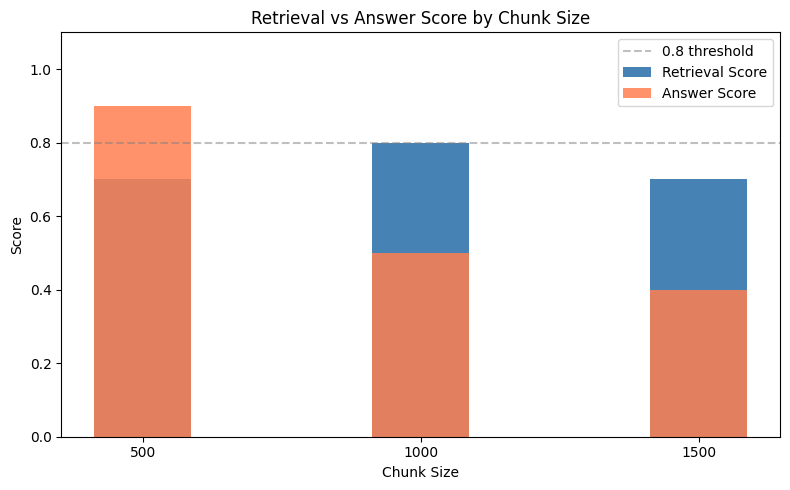

In [ ]:
import matplotlib.pyplot as plt

x = experiment_results_df["chunk_size"].astype(str)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(
    x, experiment_results_df["avg_retrieval"], 
    width, 
    label="Retrieval Score", 
    color="steelblue"
)
bars2 = ax.bar(
    [str(int(c)) for c in experiment_results_df["chunk_size"]], experiment_results_df["avg_answer"], 
    width, 
    label="Answer Score", 
    color="coral",
    bottom=0, 
    alpha=0.85
)

ax.set_xlabel("Chunk Size")
ax.set_ylabel("Score")
ax.set_title("Retrieval vs Answer Score by Chunk Size")
ax.set_ylim(0, 1.1)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="0.8 threshold")
ax.legend()

plt.tight_layout()
plt.savefig("chunk_size_experiment.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Rebuild Vectorstore w/ Best Chunk Size and Overlap

In [24]:
final_retriever, final_chain, final_chunk_count = build_vectorstore_with_chunk_size(documents, embeddings, chunk_size=500, chunk_overlap=100)
print(f"Final Chunk Count: {final_chunk_count}")

chunk_size=500, overlap=100 -> 1007 chunks
Final Chunk Count: 1007


In [25]:
# final sanity check - Should refer to 52.204-21
final_result = final_chain.invoke({
    'input':'What clause is required for basic safeguarding of covered contractor information systems?',
    'chat_history':[]
})
print(final_result['answer'])

 The clause required for basic safeguarding of covered contractor information systems is 52.204-21, Basic Safeguarding of Covered Contractor Information Systems. According to the provided context, this clause should be inserted in solicitations and contracts (except for acquisitions of COTS items), as prescribed in 4.1903.


## 9. Summary

A complete RAG pipeline for querying FAR/DFARS defense acquisition regulations.

**Key findings:**
- chunk_size=500 outperformed 1000 and 1500
- MMR retrieval successfully pulled relevant chunks across multiple PDFs
- Grounded prompting w/ source citation instructions reduced hallucination

**Potential next improvements:**
- Reranking w/ a cross-encoder after MMR retrieval
- Hybrid search combing dense embeddings w/ BM25 keyword search (useful for exact clause number lookups like "52.204-21)
- Fine-tuning the embedding model on FARS/DFARS terminology
- Streamlit UI w/ document upload for non-technical users